```21/06/2026```

# Imbplementation of B-Splines method to solve the Schrödinger's Equation

Starting with defining points, knots and their multiplicity

In [1]:
import numpy as np

In [2]:
# breakpoints 
chi = np.array([0, 1, 2, 3, 4, 5])

# Polynomial order
ell = len(chi) - 1
k = 3

# continuity conditions
nu = np.array([k] + [1] * (len(chi) - 2) + [k])

# multiplicity
mu = k - nu

# Knots
t = np.concatenate([[chi[j]] * nu[j] for j in range(len(chi)) ])

# number of basis functions
n = k + ell - 1

In [3]:
print(f"Breakpoints: {chi}")
print(f"Polynomial order: {k}")
print(f"Multiplicity: {nu}")
print(f"Continuity: {mu}")
print(f"Knots: {t}")
print(f"Number of basis functions: {n}")

Breakpoints: [0 1 2 3 4 5]
Polynomial order: 3
Multiplicity: [3 1 1 1 1 3]
Continuity: [0 2 2 2 2 0]
Knots: [0 0 0 1 2 3 4 5 5 5]
Number of basis functions: 7


We'll use `scipy`'s B-splines implementation, then we'll compare it to our own:

In [4]:
from scipy.interpolate import BSpline
import matplotlib.pyplot as plt

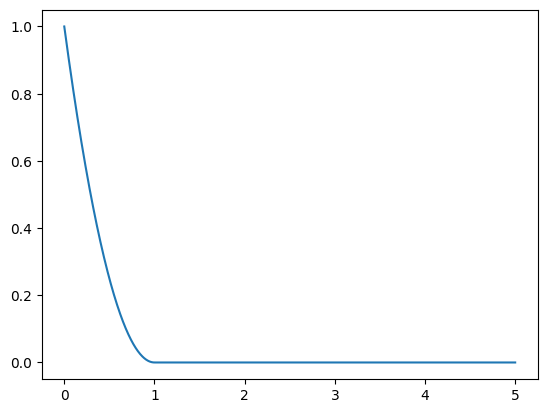

In [5]:
coefficients = np.zeros(n)
coefficients[0] = 1  # Set the first coefficient to 1 for the first basis function

spline = BSpline(t, coefficients, k-1)
x_vec = np.linspace(chi[0], chi[-1], 1000)
y2 = spline(x_vec)
plt.plot(x_vec, y2)

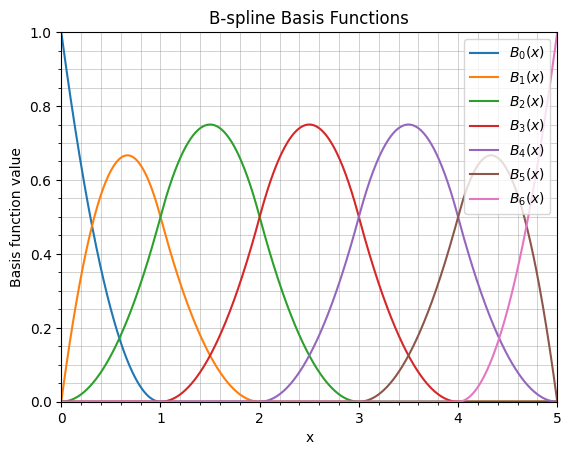

In [6]:
# Scipy uses the degree of the polynomial, not the order
kp = k-1

for i in range(n):#[1:-1]:
    coefficients = np.zeros(n)
    coefficients[i] = 1  # Set the i-th coefficient to 1 for the i-th basis function
    spline = BSpline(t, coefficients, kp, extrapolate=False)
    y = spline(x_vec)
    plt.plot(x_vec, y, label=f'$B_{i}(x)$')

plt.ylim(0, 1)
plt.xlim(chi[0], chi[-1])
plt.title('B-spline Basis Functions')
plt.xlabel('x')
plt.ylabel('Basis function value')
plt.minorticks_on()
plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5)
plt.legend()
plt.show()

Thus, Bachau's example basis is reproduced easily by the knot sequence. Next, we'll manually implement
the recursive relation that defines the B-splines:


In [7]:
def recursive_relation(x, k, t, i):

    if k == 1:
        return 1 if (t[i] <= x <= t[i+1]) else 0
    else:
        if (t[i+k-1] == t[i]):
            c1 = 0
        else:
            c1 = (x - t[i]) / (t[i+k-1] - t[i]) * recursive_relation(x, k-1, t, i)
        if (t[i+k] == t[i+1]):
            c2 = 0
        else:
            c2 = (t[i+k] - x) / (t[i+k] - t[i+1]) * recursive_relation(x, k-1, t, i+1)
            
        return c1 + c2

In [8]:
y_vec = []
for x in x_vec:
    y_vec.append(recursive_relation(x, 3, t, 3))

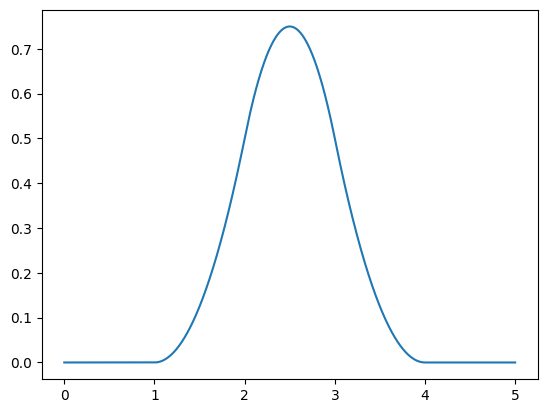

In [9]:
plt.plot(x_vec, y_vec)

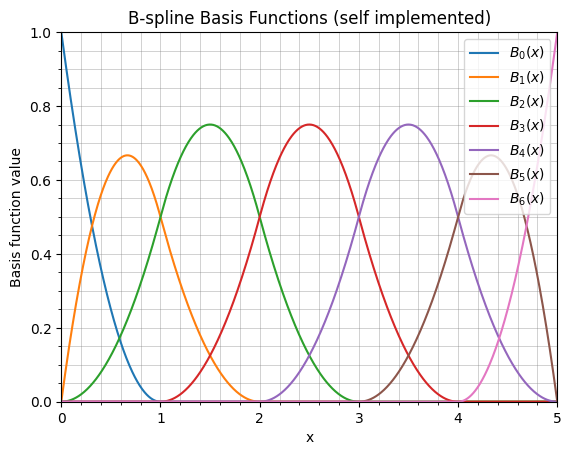

In [10]:
for i in range(n):
    for x in x_vec:
        y_vec = [recursive_relation(x, k, t, i) for x in x_vec]
    plt.plot(x_vec, y_vec, label=f'$B_{i}(x)$')

plt.ylim(0, 1)
plt.xlim(chi[0], chi[-1])
plt.title('B-spline Basis Functions (self implemented)')
plt.xlabel('x')
plt.ylabel('Basis function value')
plt.minorticks_on()
plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5)
plt.legend()
plt.show()

The basis is identically reproduced. We'll stick to `scipy`'s class as it is already well optimized. 
Next we check some random linear combinations of splines represented by this basis:

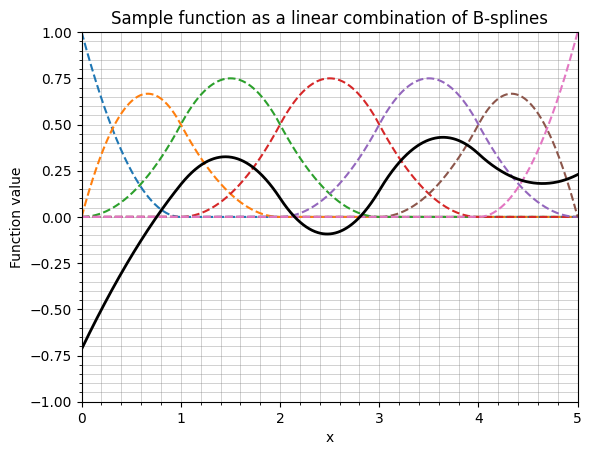

In [11]:
coeffs = np.random.rand(n)*2 - 1  # Random coefficients in the range [-1, 1]

for i in range(n):
    basis_func = BSpline(t, np.eye(n)[i], k-1, extrapolate=False)
    plt.plot(x_vec, basis_func(x_vec), label=f'$B_{i+1}(x)$', ls='dashed')
func = BSpline(t, coeffs, k-1, extrapolate=False)(x_vec)
plt.plot(x_vec, func, label='Linear combination of B-splines', color='black', linewidth=2)

plt.ylim(-1, 1)
plt.xlim(chi[0], chi[-1])
plt.title('Sample function as a linear combination of B-splines')
plt.xlabel('x')
plt.ylabel('Function value')
plt.minorticks_on()
plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5)
# plt.legend()
plt.show()

Non-unifor breakpoint sequences work too. Smoothly deforming the spline basis
functions:

In [12]:
# Non uniform breakpoints

# breakpoints 
chi = np.logspace(0, 2, 11)
# Polynomial order
ell = len(chi) - 1
k = 3

# multiplicity
mu = np.array([k] + [1] * (len(chi) - 2) + [k])

# Knots
t = np.concatenate(([chi[0]] * k, chi[1:-1], [chi[-1]] * k))

# number of basis functions
n = k + ell - 1

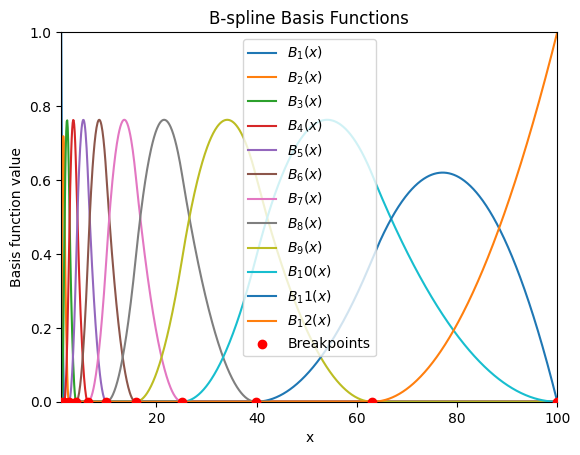

In [13]:
x_vec = np.linspace(chi[0], chi[-1], 1000)
for i in range(n):
    for x in x_vec:
        c = np.zeros(n) ; c[i] = 1
        y_vec = BSpline(t, c, k-1, extrapolate=False)(x_vec)
    plt.plot(x_vec, y_vec, label=f'$B_{i+1}(x)$')

plt.ylim(0, 1)
plt.xlim(chi[0], chi[-1])
plt.title('B-spline Basis Functions')
plt.xlabel('x')
plt.ylabel('Basis function value')
plt.scatter(chi, np.zeros_like(chi), color='red', label='Breakpoints', zorder=5)
plt.legend()

### Self developed implementation: B-spline basis set

First, we create a function dedicated to performing Gauss-Legendre quadrature
of a function `func` over the interval $[a, b]$:

In [14]:
from scipy.special import roots_legendre


def gauss_legendre_quadrature(func: callable, a: float, b: float, N: int) -> float:
    """
    Gauss-Legendre Quadrature for numerical integration.

    Parameters:
    func : callable
        The function to integrate.
    a : float
        The lower limit of integration.
    b : float
        The upper limit of integration.
    N : int
        The number of quadrature points (degree of the Legendre polynomial).
    """

    # Compute the roots and weights for the N-th degree Legendre polynomial
    roots, weights = roots_legendre(N)
    
    # Transform the roots to the interval [a, b]
    transformed_roots = 0.5 * (b - a) * roots + 0.5 * (b + a)
    
    # Evaluate the function at the transformed roots
    func_values = func(transformed_roots)
    
    # Compute the quadrature result
    result = 0.5 * (b - a) * np.dot(weights, func_values)
    
    return result

In [15]:
from warnings import warn

The `BSplineBasis` class provides the API necessary to initiate a spline basis,
generate its knots and instantiate the individual `BSpline`s. The basis also 
automatically computes the overlap matrix, the kinectic term of a hamiltonian
drawn from the basis and a general *braket* with a specific function, this being
useful to construct the hamiltonian matrix projected in this basis.

In [16]:
class BSplineBasis:

    '''
    Basic class for generating a set of Bsplines given a particular breakpoint
    sequence. 
    '''

    def __init__(self, breakpoint_sequence: np.ndarray, order: int):
        '''
        Initialize the B-spline basis with a given breakpoint sequence and order.'''
        self.order                 = order
        self.degree                = order - 1
        self.number_points         = len(breakpoint_sequence)
        self.number_intervals      = self.number_points - 1
        self.breakpoint_sequence   = breakpoint_sequence
        self.multiplicity_sequence = self.multiplicity_from_breakpoints()
        self.continuity_sequence   = self.order - self.multiplicity_sequence
        self.knot_sequence         = self.knots_from_breakpoints()
        self.number_functions      = self.number_intervals + self.order - 1
        self.basis_functions       = self.generate_basis_functions()
        self.overlap               = self.overlap_matrix()
        self.kinetic               = self.kinetic_matrix()


    def multiplicity_from_breakpoints(self):
        """
        Calculates the knot multiplicity vector from a given breakpoints 
        sequence as: [k, 1, 1, ..., 1, k].
        """

        nu = np.array([self.order] + [1] * (self.number_points - 2) + [self.order])
        return nu

    def knots_from_breakpoints(self):
        """
        Generates the full knot sequence given the multiplicity of each
        breakpoint.
        """

        t = np.concatenate([[self.breakpoint_sequence[j]] * self.multiplicity_sequence[j] \
                            for j in range(self.number_points) ])
        return t

    def generate_basis_functions(self):
        """
        Generates the full basis functions using SciPy's `BSpline` object.
        """

        basis_functions = []
        for i in range(self.number_functions):
            coeff = np.eye(self.number_functions)[i]
            basis_function = BSpline(self.knot_sequence, coeff, self.degree,
                                        extrapolate=False)
            basis_functions.append(basis_function)
        return basis_functions

    def overlap_matrix(self, extra_integration_points: int = 0):
        '''
        Compute the overlap matrix for the B-spline basis functions.
        '''
        # Initialize the overlap matrix, N by N, where N is the number of 
        # basis functions
        overlap = np.zeros((self.number_functions, self.number_functions))

        # k points are enough to compute exactly a 2k - 1 degree polynomial
        integration_points = self.order + extra_integration_points

        # Iterate over each knot interval to apply the quadrature rule
        for m in range(self.number_intervals):
            # Integration limits for the current interval
            a = self.breakpoint_sequence[m]
            b = self.breakpoint_sequence[m+1]

            # Iterate over the k basis functions that are non-zero in the 
            # current interval
            for i in range(m, m+self.order):
                for j in range(i, m+self.order):
                    integrand = lambda x: \
                        self.basis_functions[i](x)*self.basis_functions[j](x)
                    # Use Gauss-Legendre quadrature to compute the integral 
                    # over [a, b] using k points to integrate the polynomial 
                    # of degree 2k-2 exactly
                    Sij = gauss_legendre_quadrature(integrand, a, b, integration_points)

                    overlap[i, j] += Sij

        # Symmetrize the overlap matrix
        S = overlap + overlap.T - np.diag(overlap.diagonal())
                    
        return S

    def kinetic_matrix(self, extra_integration_points: int = 0):
        '''
        Compute the kinetic matrix for the B-spline basis functions.
        ∫ Bᵢ(x)B''ₖ(x) dx
        '''
        # k-1 points are enough to compute exactly a 2k - 3 degree polynomial
        integration_points = self.degree + extra_integration_points

        # Initialize the kinetic matrix, N by N, where N is the number of 
        # basis functions
        kinetic = np.zeros((self.number_functions, self.number_functions))

        # Iterate over each knot interval to apply the quadrature rule
        for m in range(self.number_intervals):

            # Integration limits for the current interval
            a = self.breakpoint_sequence[m]
            b = self.breakpoint_sequence[m+1]

            # Iterate over the basis functions that are non-zero in the 
            # current interval
            for i in range(m, m+self.order):
                for j in range(i, m+self.order):
                    integrand = lambda x: \
                        self.basis_functions[i](x)*self.basis_functions[j](x, nu=2)
                    # Use Gauss-Legendre quadrature to compute the integral 
                    # over [a, b] using k-1 points to integrate the polynomial 
                    # of degree 2k-4 exactly
                    Kij = gauss_legendre_quadrature(integrand, a, b, integration_points)

                    kinetic[i, j] += Kij

        # Symmetrize the kinetic matrix
        K = kinetic + kinetic.T - np.diag(kinetic.diagonal())
        
        return K
    
    def braket(self, func: callable, extra_integration_points: int = 0):
        '''
        Compute the bra-ket <Bᵢ|f|Bₖ> in the B-spline basis.
        '''
        if extra_integration_points == 0:
            warn(f"No extra integration points specified per interval."
                 f"integration with {self.order} points will not be accurate.")
        integration_points = self.order + extra_integration_points

        # Initialize the braket matrix, N by N, where N is the number of 
        # basis functions
        braket = np.zeros((self.number_functions, self.number_functions))

        # Iterate over each breakpoint interval to apply the quadrature rule
        for m in range(self.number_intervals):

            # Integration limits for the current 
            # breakpoint interval
            a = self.breakpoint_sequence[m]
            b = self.breakpoint_sequence[m+1]

            # Iterate over the basis functions that are non-zero in the 
            # current interval
            for i in range(m, m+self.order):
                for j in range(i, m+self.order):
                    integrand = lambda x: \
                        self.basis_functions[i](x)*func(x)*self.basis_functions[j](x)
                    # Use Gauss-Legendre quadrature to compute the integral 
                    # over [a, b] using extra points to integrate the polynomial 
                    # of degree 2k-2 times the function, which may not be 
                    # polynomial, to machine accuracy
                    Bij = gauss_legendre_quadrature(integrand, a, b, integration_points)

                    braket[i, j] += Bij

        # Symmetrize the braket matrix

        B = braket + braket.T - np.diag(braket.diagonal())
        
        return B

    # ------------------------------------------------------------
    # Boundary-condition machinery
    # ------------------------------------------------------------

    def _boundary_operator(self, side, bc):
        """
        Construct the row vector L such that

            L @ c = 0

        represents the requested homogeneous boundary condition.

        Parameters
        ----------
        side : {"left", "right"}
            Boundary at the beginning or end of the interval.

        bc : None, "dirichlet", "neumann", or tuple
            Boundary condition.

            "dirichlet":
                f = 0

            "neumann":
                f' = 0

            (alpha, beta):
                alpha*f + beta*f' = 0

        Returns
        -------
        L : ndarray, shape (N,)
            Boundary-condition row.
        """

        N = self.number_functions

        if bc is None:
            return None

        # Convert convenient strings to (alpha, beta)
        if bc == "dirichlet":
            alpha, beta = 1.0, 0.0

        elif bc == "neumann":
            alpha, beta = 0.0, 1.0

        elif isinstance(bc, (tuple, list, np.ndarray)):
            if len(bc) != 2:
                raise ValueError(
                    "Robin BC must be given as (alpha, beta)."
                )

            alpha, beta = bc

        else:
            raise ValueError(
                "BC must be None, 'dirichlet', 'neumann', "
                "or (alpha, beta)."
            )

        # Determine endpoint
        if side == "left":
            x = self.breakpoint_sequence[0]

        elif side == "right":
            x = self.breakpoint_sequence[-1]

        else:
            raise ValueError("side must be 'left' or 'right'.")

        L = np.zeros(N)

        # Evaluate alpha*B_i(x) + beta*B_i'(x)
        for i, B in enumerate(self.basis_functions):

            value = B(x)

            derivative = B.derivative(1)(x)

            L[i] = alpha * value + beta * derivative

        return L

    # def constrained_basis(
    #     self,
    #     left=None,
    #     right=None,
    #     return_matrix=True
    # ):
    #     """
    #     Construct a basis satisfying homogeneous boundary conditions.

    #     Parameters
    #     ----------
    #     left : None, "dirichlet", "neumann", or (alpha, beta)
    #         Boundary condition at x = a.

    #     right : None, "dirichlet", "neumann", or (alpha, beta)
    #         Boundary condition at x = b.

    #     return_matrix : bool
    #         If True, return C.

    #     Returns
    #     -------
    #     C : ndarray
    #         Transformation matrix satisfying

    #             c = C @ q

    #         where c are coefficients in the original B-spline
    #         basis and q are coefficients in the constrained basis.

    #     """

    #     N = self.number_functions

    #     constraints = []

    #     L_left = self._boundary_operator("left", left)
    #     L_right = self._boundary_operator("right", right)

    #     if L_left is not None:
    #         constraints.append(L_left)

    #     if L_right is not None:
    #         constraints.append(L_right)

    #     # No constraints
    #     if len(constraints) == 0:
    #         return np.eye(N)

    #     A = np.vstack(constraints)
    #     print(A)

    #     # --------------------------------------------------------
    #     # Find a basis for null(A).
    #     #
    #     # Every vector c in this nullspace satisfies
    #     #
    #     #     A @ c = 0
    #     #
    #     # --------------------------------------------------------

    #     U, s, Vh = np.linalg.svd(A)

    #     tolerance = np.max(A.shape) * np.finfo(float).eps * np.max(s)

    #     rank = np.sum(s > tolerance)

    #     C = Vh[rank:].T

    #     return C
        
    # def constrained_basis(self, left=None, right=None): 

    #     N = self.number_functions
    
    #     left = left.lower() if isinstance(left, str) else left
    #     right = right.lower() if isinstance(right, str) else right
    
    #     # ------------------------------------------------------------
    #     # Simple homogeneous Dirichlet conditions
    #     # ------------------------------------------------------------
    
    #     if left == "dirichlet" and right == "dirichlet":
    #         return np.eye(N)[:, 1:-1]
    
    #     if left == "dirichlet" and right is None:
    #         return np.eye(N)[:, 1:]
    
    #     if left is None and right == "dirichlet":
    #         return np.eye(N)[:, :-1]
    
    #     if left is None and right is None:
    #         return np.eye(N)
    
    #     raise NotImplementedError(
    #         "Only Dirichlet conditions are implemented in this draft."
    #     )


    def constrained_basis(self, left=None, right=None):
        """
        Build C such that c = C @ q maps boundary-adapted coefficients q
        back to the original B-spline coefficients c, satisfying the
        requested homogeneous BC(s) at each end.
    
        Exploits the fact that, for a clamped knot vector, a first-order
        BC at x=a only ever couples B_0 and B_1 (and symmetrically
        B_{N-1}, B_{N-2} at x=b) — so each BC is eliminated with a local
        2x2 combination instead of a dense nullspace computation. This
        keeps C sparse/near-identity, so it preserves the banded
        structure of S and K under C.T @ S @ C.
        """
        N = self.number_functions
        C = np.eye(N)
        keep = list(range(N))
    
        if left is not None:
            L = self._boundary_operator("left", left)
            l0, l1 = L[0], L[1]
            if np.isclose(l1, 0.0):
                # value-only constraint (e.g. Dirichlet): c_0 forced to 0
                keep.remove(0)
            else:
                # c_1 = -(l0/l1) c_0  -> fold into a single edge function
                C[1, 0] = -l0 / l1
                keep.remove(1)
    
        if right is not None:
            L = self._boundary_operator("right", right)
            lNm1, lNm2 = L[-1], L[-2]
            if np.isclose(lNm2, 0.0):
                keep.remove(N - 1)
            else:
                C[N - 2, N - 1] = -lNm1 / lNm2
                keep.remove(N - 2)
    
        return C[:, keep]

Reproducing Bachau's sample basis:

In [17]:
# breakpoints
chi = np.array([0, 1, 2, 3, 4, 5])
# Polynomial order
k = 3
# number of intervals
ell = len(chi) - 1
# continuity conditions
nu = np.array([k] + [1] * (len(chi) - 2) + [k])

# multiplicity
mu = k - nu

# Knots
t = np.concatenate([[chi[j]] * nu[j] for j in range(len(chi)) ])

# number of basis functions
n = k + ell - 1

In [18]:
print("="*10 + "Reference" + "="*10)
print(f"Breakpoints: {chi}")
print(f"Polynomial order: {k}")
print(f"Continuity {mu}")
print(f"Multiplicity: {nu}")
print(f"Knots: {t}")

==========Reference==========
Breakpoints: [0 1 2 3 4 5]
Polynomial order: 3
Continuity [0 2 2 2 2 0]
Multiplicity: [3 1 1 1 1 3]
Knots: [0 0 0 1 2 3 4 5 5 5]


We instantiate the class, the process is simple since the basis is fully determine from polynomial
order and the breakpoint sequence. The defining vectors of the basis are eagerly calculated, and so
are the overlap and kinetic matrices, used to define the hamiltonian of a quantum system:

In [19]:
spline_basis = BSplineBasis(chi, k)

In [20]:
print("="*10 + "Through the class" + "="*10)
print(f"Breakpoints: {spline_basis.breakpoint_sequence}")
print(f"Polynomial order: {spline_basis.order}")
print(f"Continuity {spline_basis.continuity_sequence}")
print(f"Multiplicity: {spline_basis.multiplicity_sequence}")
print(f"Knots: {spline_basis.knot_sequence}")

==========Through the class==========
Breakpoints: [0 1 2 3 4 5]
Polynomial order: 3
Continuity [0 2 2 2 2 0]
Multiplicity: [3 1 1 1 1 3]
Knots: [0 0 0 1 2 3 4 5 5 5]


The basis' `overlap` property holds the overlap matrix, given by $S_{ij} = \int_a^b B_i(x)B_j(x) \mathrm d x$, 
while the `kinetic` property contains the matrix: $K_{ij} = -\dfrac{1}{2} \int_a^b B_i(x)B''_j(x) \mathrm d x$, 
used to define the kinetic term of the hamiltonian.

These calculations take advantage of the compact support of the basis and utilize Gauss-Legendre quadrature to
exactly compute the polynomial integrals.

In [22]:
from fractions import Fraction

S = spline_basis.overlap

#print the overlap matrix with fractions in matrix form

print("="*20 + "Overlap matrix" + "="*20)

for i in range(S.shape[0]):
    row = [str(Fraction(S[i, j]).limit_denominator()) + "\t" for j in range(S.shape[1])]
    print(*row)


====================Overlap matrix====================
1/5	 7/60	 1/60	 0	 0	 0	 0	
7/60	 1/3	 5/24	 1/120	 0	 0	 0	
1/60	 5/24	 11/20	 13/60	 1/120	 0	 0	
0	 1/120	 13/60	 11/20	 13/60	 1/120	 0	
0	 0	 1/120	 13/60	 11/20	 5/24	 1/60	
0	 0	 0	 1/120	 5/24	 1/3	 7/60	
0	 0	 0	 0	 1/60	 7/60	 1/5	


In [24]:
K = spline_basis.kinetic

#print the kinetic matrix with fractions in matrix form

print("="*20 + "Kinetic matrix" + "="*20)

for i in range(K.shape[0]):
    row = [str(Fraction(K[i, j]).limit_denominator()) + "\t" for j in range(K.shape[1])]
    print(*row)


====================Kinetic matrix====================
2/3	 -1	 1/3	 0	 0	 0	 0	
-1	 -4/3	 1/6	 1/6	 0	 0	 0	
1/3	 1/6	 -1	 1/3	 1/6	 0	 0	
0	 1/6	 1/3	 -1	 1/3	 1/6	 0	
0	 0	 1/6	 1/3	 -1	 1/6	 1/3	
0	 0	 0	 1/6	 1/6	 -4/3	 1	
0	 0	 0	 0	 1/3	 1	 2/3	


The `basis_functions` property contains the individual SciPy `BSpline` instances used to plot and calculations:

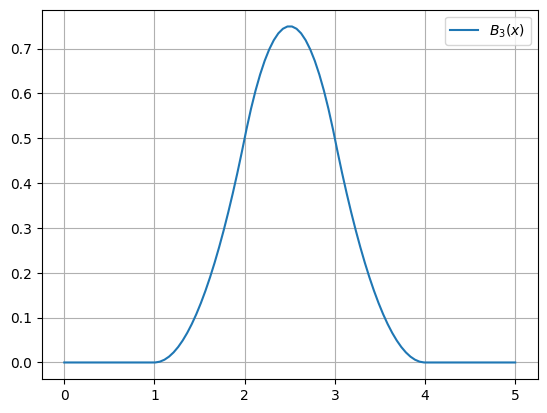

In [25]:
x_vec = np.linspace(chi[0], chi[-1], 100)

plt.plot(x_vec, spline_basis.basis_functions[3](x_vec), label='$B_3(x)$')
plt.legend()
plt.grid()

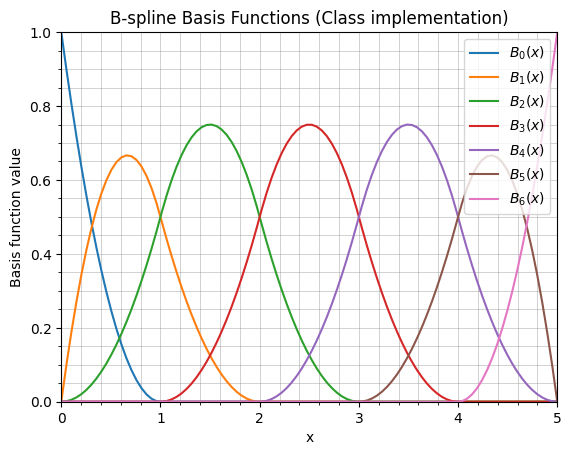

In [26]:
# Original basis
for i in range(spline_basis.number_functions):
    plt.plot(x_vec, spline_basis.basis_functions[i](x_vec), label=f'$B_{i}(x)$')

plt.ylim(0, 1)
plt.xlim(chi[0], chi[-1])
plt.title('B-spline Basis Functions (Class implementation)')
plt.xlabel('x')
plt.ylabel('Basis function value')
plt.minorticks_on()
plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5)
plt.legend()
plt.show()

Finally, boundary condition implementation was introduced through the matrix $C$ connecting original
coefficients from constrained coefficients: `"dirichlet"`, `"neumann"` and `(alpha, beta)`, the latter
referring to the general Robin boundary condition:

$$
    \alpha f(x) + \beta f'(x) = 0
$$

In [27]:
C = spline_basis.constrained_basis(left="dirichlet", right="dirichlet")
C

array([[0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.]])

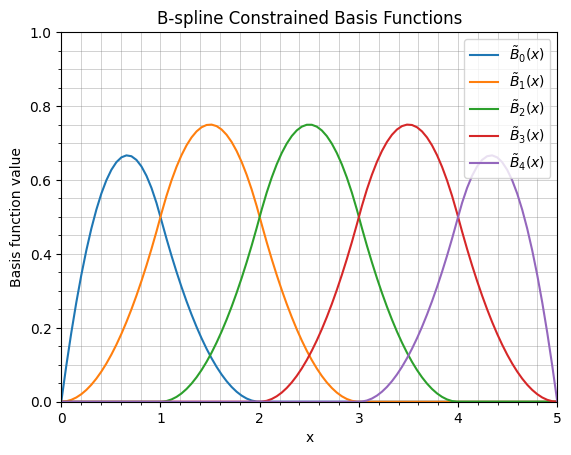

In [28]:
# Constrained basis
for i in range(C.shape[1]):
    coeffs = C[:, i]
    constrained_basis_function_vals = sum(coeff * spline_basis.basis_functions[j](x_vec) for j, coeff in enumerate(coeffs))
    plt.plot(x_vec, constrained_basis_function_vals, label=f'$\\tilde{{B}}_{i}(x)$')

plt.ylim(0, 1)
plt.xlim(chi[0], chi[-1])
plt.title('B-spline Constrained Basis Functions')
plt.xlabel('x')
plt.ylabel('Basis function value')
plt.minorticks_on()
plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5)
plt.legend()
plt.show()

### Solving the Schrödinger equation with B-splines

The limited Bachau basis is a valid proof of concept, but it's time to tackle the real problem.
Let's start by trying to obtain the Balmer series for the hydrogen atom using a 1D Coulomb
potential. The corresponding 1D time-independent S.E is stated as:

$$
    -\frac{1}{2}\frac{\mathrm d^2}{\mathrm d r^2} \psi(r) + V(r) \psi(r) = E \psi(r)
$$

Representing $\psi(r)$ as $\vec c \cdot \vec B(r)$:

$$
    -\frac{1}{2}\frac{\mathrm d^2}{\mathrm d r^2} \sum_{i=0}^{N-1} c_i B_i(r) + V(r) \sum_{i=0}^{N-1} c_i B_i(r) = E \sum_{i=0}^{N-1} c_i B_i(r)
$$

Projecting onto $B_j(r)$:

$$
    -\frac{1}{2} \sum_{i=0}^{N-1} c_i \int_a^b B_j(r) \frac{\mathrm d^2}{\mathrm d r^2} B_i(r) \mathrm d r 
    + \sum_{i=0}^{N-1} c_i \int_a^b B_j(r) V(r) B_i(r) \mathrm d r 
    = E \sum_{i=0}^{N-1} c_i \int_a^b B_j(r) B_i(r) \mathrm d r
$$

Collecting terms into matrix form:

$$
\begin{align}
    T_{ij} &= -\frac{1}{2} \int_a^b B_j(r) \frac{\mathrm d^2}{\mathrm d r^2} B_i(r) \mathrm d r \nonumber \\ 
    \Phi_{ij} &= \int_a^b B_j(r) V(r) B_i(r) \mathrm d r \nonumber \\
    S_{ij} &= \int_a^b B_j(r) B_i(r) \mathrm d r  \nonumber
\end{align}
\\
\\[15pt]
\fbox{ $H = T + \Phi$ }
$$

This yields the following **generalized eigenproblem**:

$$
    H \vec c = E S \vec c
$$

Solving this using `scipy.linalg.eigh(H, S)` readily yields the energies as eigenvalues and the
coefficients in the B-spline basis as the eigenvectors. To demonstrate this procedure, let's solve the
1D Coulomb potential and compare to the balmer series:

In [29]:
def coulomb(x):
    return -1/x

/tmp/ipykernel_120964/2289209397.py:2: RuntimeWarning: divide by zero encountered in divide
  return -1/x


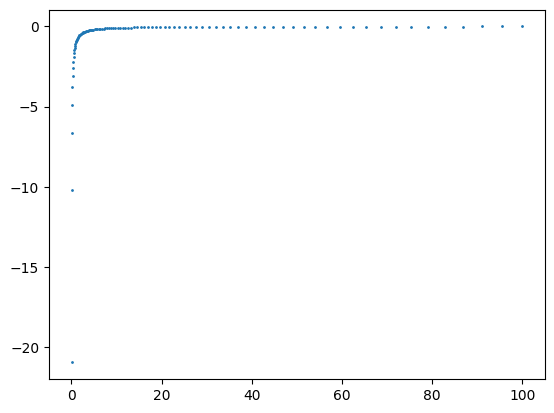

In [30]:
# limits
rm, rM = 0, 100

#logarithmic breakpoints -- 100 points
bps = np.logspace(np.log10(rm + 1), np.log10(rM + 1), 100) - 1

plt.scatter(bps, coulomb(bps), s=1)

In [31]:
# Polynomial order
k = 9
coulomb_basis = BSplineBasis(bps, k)

In [32]:
r_vec = np.linspace(bps[0], bps[-1], 100000)

In [33]:
C = coulomb_basis.constrained_basis(left="dirichlet", right="dirichlet")
C

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]])

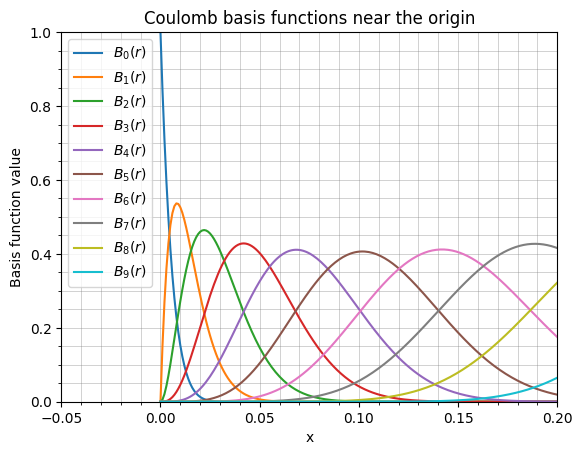

In [34]:
#basis functions
for j in range(10):
    plt.plot(r_vec, coulomb_basis.basis_functions[j](r_vec), label=f"$B_{j}(r)$")

plt.ylim(0, 1)
plt.xlim(-0.05, 0.2)
plt.title('Coulomb basis functions near the origin')
plt.xlabel('x')
plt.ylabel('Basis function value')
plt.minorticks_on()
plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5)
plt.legend()
plt.show()

In [35]:
braket1 = coulomb_basis.braket(coulomb, extra_integration_points=10)
braket2 = coulomb_basis.braket(coulomb, extra_integration_points=50)

In [36]:
braket1_constrained = C.T @ braket1 @ C
braket2_constrained = C.T @ braket2 @ C

In [37]:
np.abs(braket1_constrained-braket2_constrained)

array([[2.99760217e-15, 1.49880108e-15, 3.88578059e-16, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.49880108e-15, 1.33226763e-15, 3.88578059e-16, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.88578059e-16, 3.88578059e-16, 2.77555756e-17, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.46944695e-18, 1.47451495e-17, 8.23993651e-18],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.47451495e-17, 3.12250226e-17, 2.08166817e-17],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        8.23993651e-18, 2.08166817e-17, 2.38524478e-17]])

In [38]:
H = -(1/2)*coulomb_basis.kinetic + braket2

In [39]:
H_constrained = C.T @ H @ C

In [40]:
from scipy.linalg import eigh

In [41]:
S = coulomb_basis.overlap
S_constrained = C.T @ S @ C

In [42]:
c_energies, c_eigstates = eigh(H_constrained, S_constrained)

In [43]:
c_energies[:10]

array([-0.5       , -0.125     , -0.05555556, -0.03125   , -0.01999997,
       -0.01386848, -0.00959637, -0.00466284,  0.00165607,  0.00926674])

In [44]:
balmer = [-1/(2*n**2) for n in range(1, 11)]
balmer

[-0.5,
 -0.125,
 -0.05555555555555555,
 -0.03125,
 -0.02,
 -0.013888888888888888,
 -0.01020408163265306,
 -0.0078125,
 -0.006172839506172839,
 -0.005]

In [45]:
for i in range(10):
    print(f"Energy level {i+1}: B-spline = {c_energies[i]:.6f}, Analytical = {balmer[i]:.6f}, Percentual error = {np.abs(balmer[i]-c_energies[i])*100:.6f}%")

Energy level 1: B-spline = -0.500000, Analytical = -0.500000, Percentual error = 0.000000%
Energy level 2: B-spline = -0.125000, Analytical = -0.125000, Percentual error = 0.000000%
Energy level 3: B-spline = -0.055556, Analytical = -0.055556, Percentual error = 0.000000%
Energy level 4: B-spline = -0.031250, Analytical = -0.031250, Percentual error = 0.000000%
Energy level 5: B-spline = -0.020000, Analytical = -0.020000, Percentual error = 0.000003%
Energy level 6: B-spline = -0.013868, Analytical = -0.013889, Percentual error = 0.002041%
Energy level 7: B-spline = -0.009596, Analytical = -0.010204, Percentual error = 0.060771%
Energy level 8: B-spline = -0.004663, Analytical = -0.007812, Percentual error = 0.314966%
Energy level 9: B-spline = 0.001656, Analytical = -0.006173, Percentual error = 0.782891%
Energy level 10: B-spline = 0.009267, Analytical = -0.005000, Percentual error = 1.426674%


In [46]:
q = c_eigstates[:, 1]
c = C @ q

In [47]:
first_state = BSpline(coulomb_basis.knot_sequence, c, k=coulomb_basis.degree, extrapolate=False)

In [48]:
from scipy.special import genlaguerre

def C_eigstate(r, n):
    """
    Computes the Coulomb wavefunction φ_n(r)
    """
    # Pre-factor
    prefactor = (2 * r) / np.sqrt(n**5)
    
    # Exponential term
    exp_term = np.exp(-r/n)
    
    # Laguerre polynomial term
    #laguerre_term = Lag(n, 2 * r / n)
    laguerre_term = genlaguerre(n-1, 1)(2*r/n)
    
    func = prefactor * exp_term * laguerre_term

    # Complete wavefunction
    return np.where(r>0, func, np.zeros_like(func))

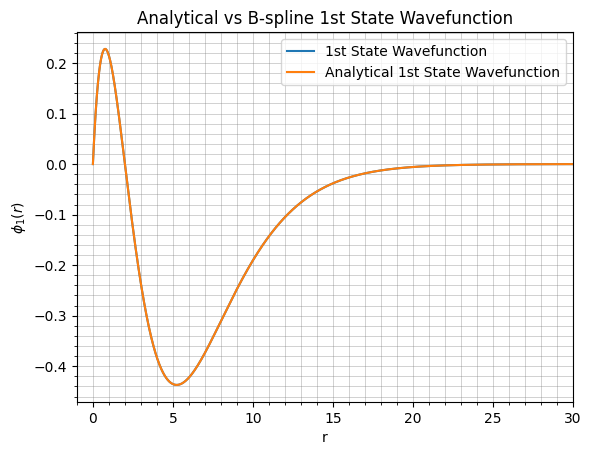

In [49]:
plt.plot(r_vec, first_state(r_vec), label='1st State Wavefunction')
plt.plot(r_vec, C_eigstate(r_vec, 2), label='Analytical 1st State Wavefunction')
plt.legend()
plt.xlim(-1, 30)

plt.title('Analytical vs B-spline 1st State Wavefunction')
plt.xlabel('r')
plt.ylabel('$\\phi_1(r)$')
plt.minorticks_on()
plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5)
plt.legend()
plt.show()

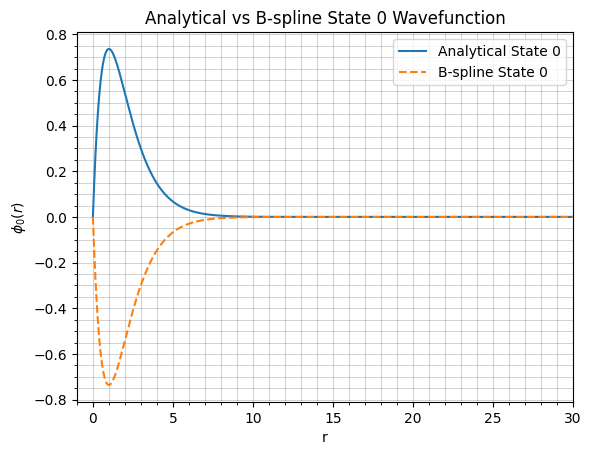

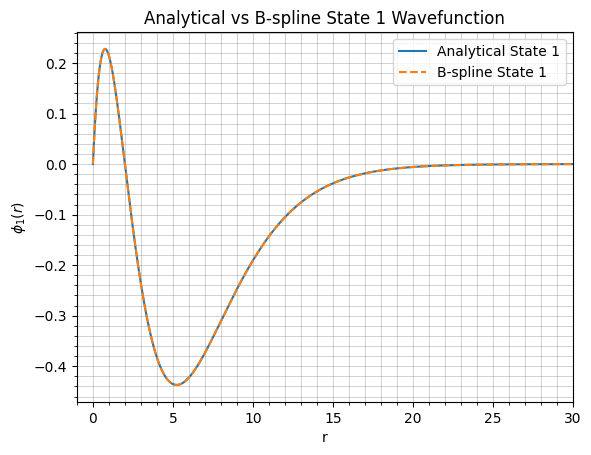

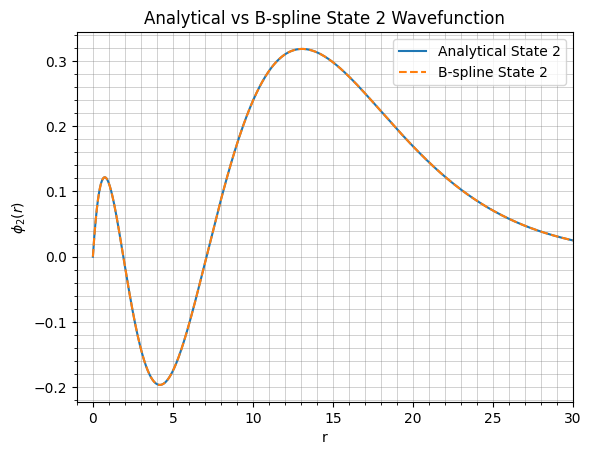

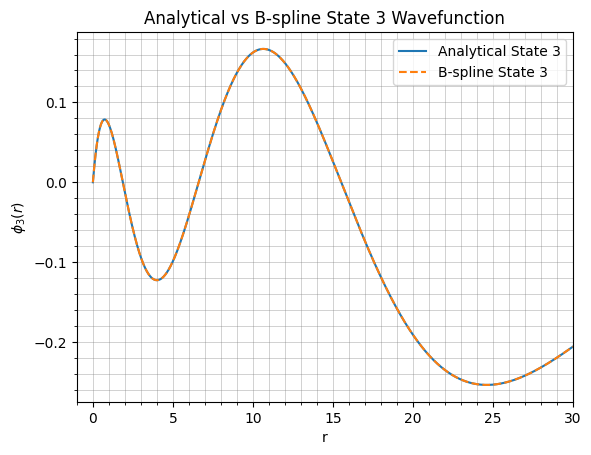

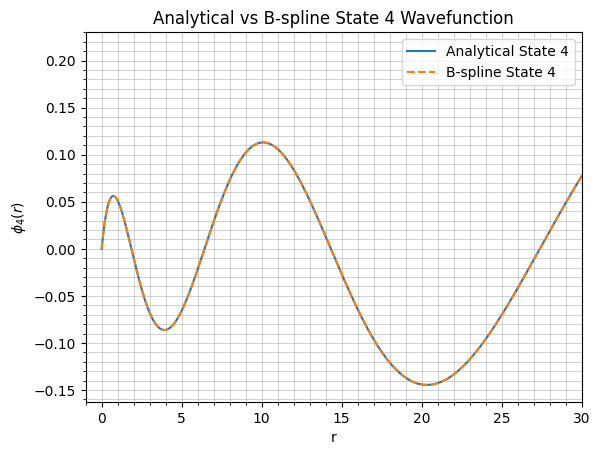

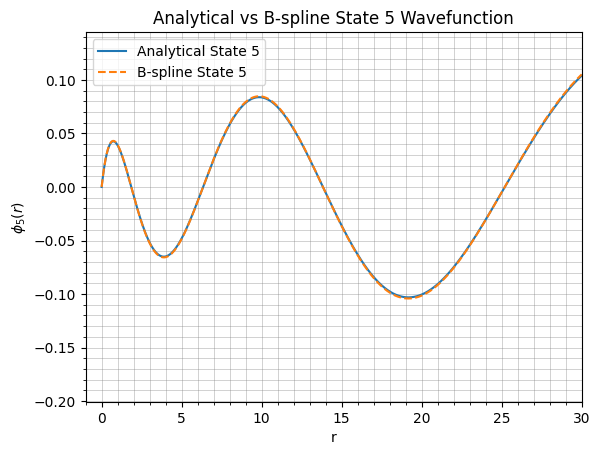

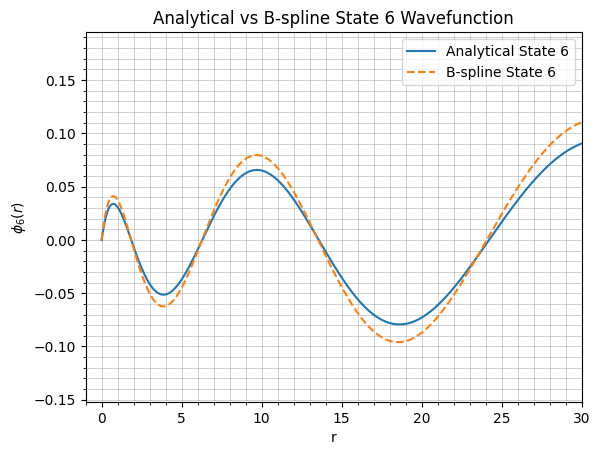

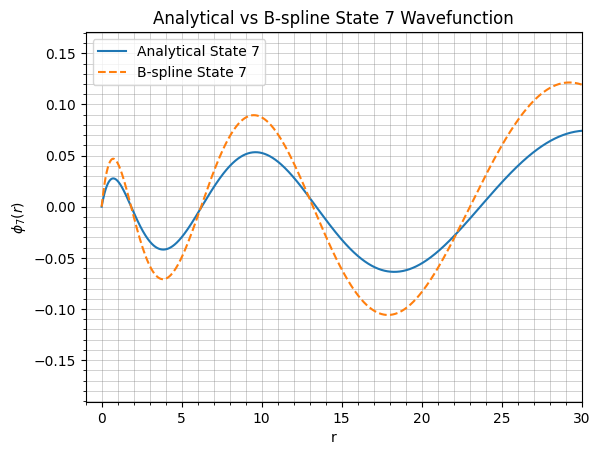

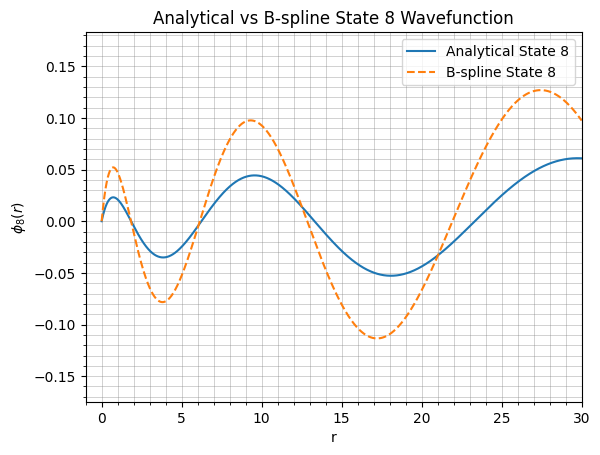

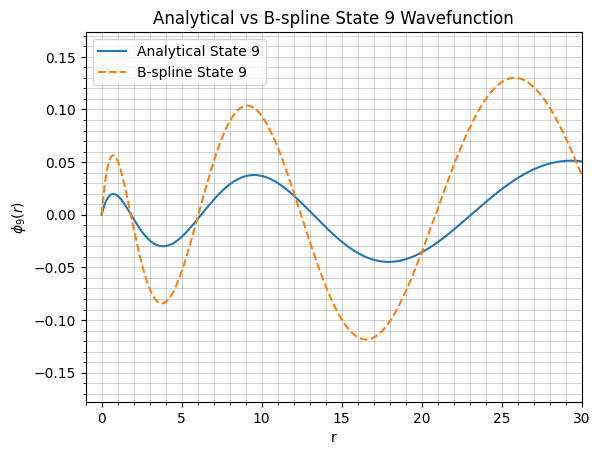

In [50]:
for i in range(10):
    plt.plot(r_vec, C_eigstate(r_vec, i+1), label=f'Analytical State {i}')
    plt.plot(r_vec, BSpline(coulomb_basis.knot_sequence, C @ c_eigstates[:, i], k=coulomb_basis.degree, extrapolate=False)(r_vec), label=f'B-spline State {i}', ls='dashed')
    plt.xlim(-1, 30)
    plt.title(f'Analytical vs B-spline State {i} Wavefunction')
    plt.xlabel('r')
    plt.ylabel(f'$\\phi_{i}(r)$')
    plt.minorticks_on()
    plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5)
    plt.legend()
    plt.show()

Success! We only need to make the calculations more direct by implementing some class that takes care
of, given a basis and potential, calculating the eigenstates and eigenenergies, sorting out a pattern
for consitently signing the eigenstate and then experiment with breakpoint sequences, number of points,
integration parameters, etc.

The redemption time is now. I'll solve for the MsC potential using this method:

In [52]:
from emerald.potentials.msc_potential import MsC_potential_vec, MsC_return_points

In [53]:
alpha = 0.1

rm, rM = MsC_return_points(alpha, 0.01)

print(f"Return points: r = {rm, rM}")
print(f"Breakpoint lims: r = {10*rm, rM}")

print(f"V_MsC at lims: {MsC_potential_vec(alpha, np.array([10*rm, rM]))}")

Return points: r = (np.float64(-0.0980611564350228), np.float64(99.99994999998749))
Breakpoint lims: r = (np.float64(-0.980611564350228), np.float64(99.99994999998749))
V_MsC at lims: [ 1.05177691e+07 -1.00000000e-02]


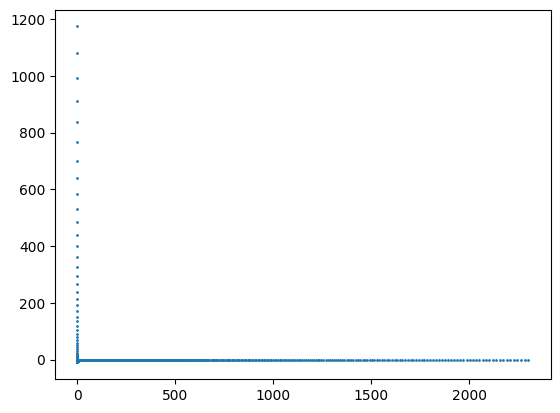

In [54]:
lowl, hil = -0.35, 2300
bps = np.logspace(np.log10(lowl + 1), np.log10(hil + 1), 1000) - 1
plt.scatter(bps, MsC_potential_vec(alpha, bps), s=1)

(-15.0, 5.0)

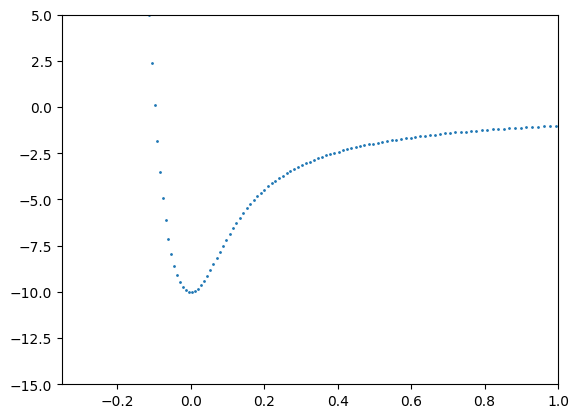

In [55]:
plt.scatter(bps, MsC_potential_vec(alpha, bps), s=1)
plt.xlim(-0.35, 1)
plt.ylim(-15, 5)

In [56]:
msc_basis = BSplineBasis(bps, 9)

In [57]:
C = msc_basis.constrained_basis(left='dirichlet', right='dirichlet')

H = -(1/2)*msc_basis.kinetic + msc_basis.braket(lambda x: MsC_potential_vec(alpha, x), 20)

H_constrained = C.T @ H @ C
S_constrained = C.T @ msc_basis.overlap @ C

In [58]:
msc_energies, msc_states = eigh(H_constrained, S_constrained)

In [59]:
print(f"r_m = {bps[0]:.2f}, energies = {msc_energies[:5]}")

r_m = -0.35, energies = [-1.21936784 -0.18628031 -0.07183621 -0.03777406 -0.02324181]


In [60]:
for i in range(10):
    print(f"energy = {msc_energies[i]}")

energy = -1.2193678445719471
energy = -0.18628031271898218
energy = -0.07183620674493778
energy = -0.037774062879281374
energy = -0.023241812577766828
energy = -0.015728551455390993
energy = -0.011346693568934757
energy = -0.008570143266016909
energy = -0.006700754244883211
energy = -0.005382429656246189


In [61]:
fortran_energies = np.array([-1.21936784728691, -0.186280312943416, -0.07183620680046786, -0.03777406290062701, -0.0232418125881086, -0.01572855146117109, -0.01134669357249879, -0.008570143268342987, -0.006700754246467339, -0.005382429657382319, -0.004418083717974149, -0.003691463789517135, -0.00313039970849324, -0.002688166263680363, -0.002333430531387182, -0.002044545101096697, -0.001806165458975417, -0.001607169492949377, -0.001439336247834685, -0.00129648302067541, -0.001173887695103805, -0.001067893433548986, -0.0009756327858560889, -0.000894831697353263, -0.000823668025647287, -0.0007606679050380154, -0.000704628814877956, -0.0006545617672567224, -0.0006096473709850504, -0.0005692020704918935, -0.0005326506283981534, -0.0004994675168865049, -0.0004687581723696942, -0.0004381787737182047, -0.0004048259892390321, -0.0003676210272417694, -0.0003267229138199131, -0.0002824561360350963, -0.0002350729136027451, -0.0001847567055423962, -0.0001316445978296417, -7.584268436628879e-05, -1.7435601137443e-05, 4.350744972322732e-05, 0.0001069287461668966, 0.0001727793477990016, 0.000241017194223751])

In [62]:
print(f"alpha = {alpha}, r_m = {bps[0]:.2f}, r_M = {bps[-1]:.2f}, N = 1000")
for i in range(30):
    print(f"energy = {msc_energies[i]:<10.10f} \t, fortran = {fortran_energies[i]:<10.10f}, percentual error = {np.abs(fortran_energies[i]-msc_energies[i])*100:.10f}%")

alpha = 0.1, r_m = -0.35, r_M = 2300.00, N = 1000
energy = -1.2193678446 	, fortran = -1.2193678473, percentual error = 0.0000002715%
energy = -0.1862803127 	, fortran = -0.1862803129, percentual error = 0.0000000224%
energy = -0.0718362067 	, fortran = -0.0718362068, percentual error = 0.0000000056%
energy = -0.0377740629 	, fortran = -0.0377740629, percentual error = 0.0000000021%
energy = -0.0232418126 	, fortran = -0.0232418126, percentual error = 0.0000000010%
energy = -0.0157285515 	, fortran = -0.0157285515, percentual error = 0.0000000006%
energy = -0.0113466936 	, fortran = -0.0113466936, percentual error = 0.0000000004%
energy = -0.0085701433 	, fortran = -0.0085701433, percentual error = 0.0000000002%
energy = -0.0067007542 	, fortran = -0.0067007542, percentual error = 0.0000000002%
energy = -0.0053824297 	, fortran = -0.0053824297, percentual error = 0.0000000001%
energy = -0.0044180837 	, fortran = -0.0044180837, percentual error = 0.0000000001%
energy = -0.0036914638 	, 

### Final boss: the super low $\alpha$

In [63]:
alpha = 0.001

rm, rM = MsC_return_points(alpha, 0.01)

print(f"Return points: r = {rm, rM}")
print(f"Breakpoint lims: r = {10*rm, rM}")

print(f"V_MsC at lims: {MsC_potential_vec(alpha, np.array([10*rm, rM]))}")

Return points: r = (np.float64(-0.000980261678989195), np.float64(99.999999995))
Breakpoint lims: r = (np.float64(-0.00980261678989195), np.float64(99.999999995))
V_MsC at lims: [ 1.04658038e+09 -1.00000000e-02]


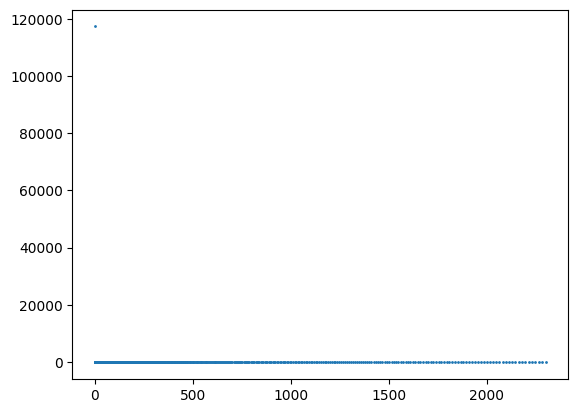

In [64]:
lowl, hil = -0.0035, 2300
bps = np.logspace(np.log10(lowl + 1), np.log10(hil + 1), 1000) - 1
plt.scatter(bps, MsC_potential_vec(alpha, bps), s=1)

(-15.0, 5.0)

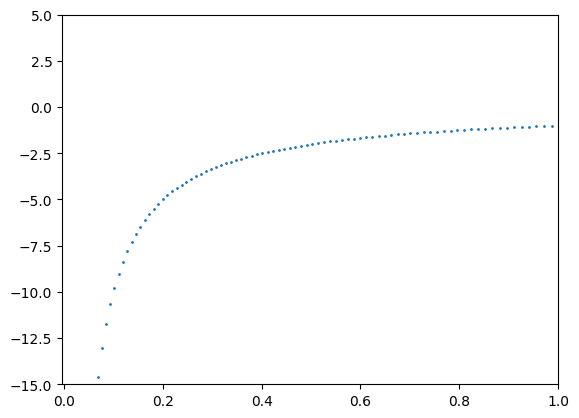

In [65]:
plt.scatter(bps, MsC_potential_vec(alpha, bps), s=1)
plt.xlim(-0.0036, 1)
plt.ylim(-15, 5)

In [66]:
msc_basis = BSplineBasis(bps, 9)

In [67]:
C = msc_basis.constrained_basis(left='dirichlet', right='dirichlet')

H = -(1/2)*msc_basis.kinetic + msc_basis.braket(lambda x: MsC_potential_vec(alpha, x), 20)

H_constrained = C.T @ H @ C
S_constrained = C.T @ msc_basis.overlap @ C

In [68]:
msc_energies, msc_states = eigh(H_constrained, S_constrained)

In [69]:
print(f"r_m = {bps[0]:.2f}, energies = {msc_energies[:5]}")

r_m = -0.00, energies = [-0.50722254 -0.12589761 -0.05582102 -0.03136189 -0.02005726]


In [70]:
for i in range(10):
    print(f"energy = {msc_energies[i]}")

energy = -0.5072225431165801
energy = -0.12589760787735543
energy = -0.05582101683773308
energy = -0.0313618882406309
energy = -0.02005725531729116
energy = -0.013922010676340737
energy = -0.01022493425462336
energy = -0.007826466914720245
energy = -0.006182647437749127
energy = -0.005007149120877782


In [71]:
fortran_energies = np.array([-0.507222763325396, -0.125897635085829, -0.05582102486895009, -0.03136189162249624, -0.02005725704697915, -0.01392201167654488, -0.01022493488416288, -0.0078264673362816, -0.006182647733743623, -0.005007149336616333, -0.004137602278576247, -0.00347635882343691, -0.002961833205078939, -0.002553625046399615, -0.002224339780703515, -0.00195486973597629, -0.001731558346259181, -0.00154443516861864, -0.00138608334715919, -0.001250893184468643, -0.00113455839463035, -0.001033728881135225, -0.0009457668262133593, -0.0008685723984839826, -0.0008004572614244504, -0.000740051467455676, -0.0006862340334880813, -0.0006380805565505091, -0.0005948232505759168, -0.0005558200488647444, -0.0005205257576427986, -0.0004883735332288607, -0.000458068486270457, -0.0004267679795468593, -0.0003920738924562749, -0.0003535208284049012, -0.0003113938582492497, -0.0002659970083972967, -0.000217555375928914, -0.0001662337334977491, -0.0001121567763534941, -5.542211900693804e-05, 3.891636515456756e-06, 6.571973443869198e-05, 0.0001300078276077827, 0.0001967096022849963, 0.0002657850846779458, 0.0003371993995941718, 0.0004109218380010479, 0.0004869251432447249, 0.0005651849530663283, 0.0006456793586164442, 0.0007283885496376972, 0.0008132945255022371, 0.000900380858426241, 0.000989632496425944, 0.001081035598165851, 0.001174577393706606, 0.001270246065851987, 0.001368030648569215, 0.001467920939853576, 0.00156990742540468, 0.001673981213400287, 0.00178013397542937, 0.001888357896794354, 0.001998645631454092, 0.002110990261887468, 0.002225385263276097, 0.00234182447303418, 0.002460302061625493, 0.00258081250776487, 0.002703350574808924, 0.002827911290498282, 0.002954489928326664, 0.003083081989755203, 0.003213683189612863, 0.003346289441569916, 0.003480896845106561, 0.003617501673633252, 0.003756100363997492, 0.00389668950645303, 0.004039265834700854, 0.004183826218396549, 0.004330367654731109, 0.004478887261478001, 0.004629382270093072])

In [72]:
print(f"alpha = {alpha}, r_m = {bps[0]:.5f}, r_M = {bps[-1]:.2f}, N = 1000")
for i in range(30):
    print(f"energy = {msc_energies[i]:<10.10f} \t, fortran = {fortran_energies[i]:<10.10f}, percentual error = {np.abs(fortran_energies[i]-msc_energies[i])*100:.10f}%")

alpha = 0.001, r_m = -0.00350, r_M = 2300.00, N = 1000
energy = -0.5072225431 	, fortran = -0.5072227633, percentual error = 0.0000220209%
energy = -0.1258976079 	, fortran = -0.1258976351, percentual error = 0.0000027208%
energy = -0.0558210168 	, fortran = -0.0558210249, percentual error = 0.0000008031%
energy = -0.0313618882 	, fortran = -0.0313618916, percentual error = 0.0000003382%
energy = -0.0200572553 	, fortran = -0.0200572570, percentual error = 0.0000001730%
energy = -0.0139220107 	, fortran = -0.0139220117, percentual error = 0.0000001000%
energy = -0.0102249343 	, fortran = -0.0102249349, percentual error = 0.0000000630%
energy = -0.0078264669 	, fortran = -0.0078264673, percentual error = 0.0000000422%
energy = -0.0061826474 	, fortran = -0.0061826477, percentual error = 0.0000000296%
energy = -0.0050071491 	, fortran = -0.0050071493, percentual error = 0.0000000216%
energy = -0.0041376021 	, fortran = -0.0041376023, percentual error = 0.0000000162%
energy = -0.003476358

... drop the mic! The results speak for themselves, the method works, and it works well. Lastly we'll implement a few helper functions to build the hamiltoninan and from it get the system's spectrum:

In [73]:
from typing import Protocol


class Representation(Protocol):
    number_functions: int
    overlap: np.ndarray
    kinetic: np.ndarray

    def braket(self, func: callable) -> np.ndarray: ...
    def reconstruct(self, coeffs: np.ndarray) -> callable: ...
    def constrained_basis(self, left, right) -> np.ndarray: ...

In [74]:
class BSplineBasis(Representation):

    '''
    Basic class for generating a set of Bsplines given a particular breakpoint
    sequence. 
    '''

    def __init__(self, breakpoint_sequence: np.ndarray, order: int):
        '''
        Initialize the B-spline basis with a given breakpoint sequence and order.'''
        self.order                 = order
        self.degree                = order - 1
        self.number_points         = len(breakpoint_sequence)
        self.number_intervals      = self.number_points - 1
        self.breakpoint_sequence   = breakpoint_sequence
        self.multiplicity_sequence = self.multiplicity_from_breakpoints()
        self.continuity_sequence   = self.order - self.multiplicity_sequence
        self.knot_sequence         = self.knots_from_breakpoints()
        self.number_functions      = self.number_intervals + self.order - 1
        self.basis_functions       = self.generate_basis_functions()
        self.overlap               = self.overlap_matrix()
        self.kinetic               = self.kinetic_matrix()


    def multiplicity_from_breakpoints(self):
        """
        Calculates the knot multiplicity vector from a given breakpoints 
        sequence as: [k, 1, 1, ..., 1, k].
        """

        nu = np.array([self.order] + [1] * (self.number_points - 2) + [self.order])
        return nu

    def knots_from_breakpoints(self):
        """
        Generates the full knot sequence given the multiplicity of each
        breakpoint.
        """

        t = np.concatenate([[self.breakpoint_sequence[j]] * self.multiplicity_sequence[j] \
                            for j in range(self.number_points) ])
        return t

    def generate_basis_functions(self):
        """
        Generates the full basis functions using SciPy's `BSpline` object.
        """

        basis_functions = []
        for i in range(self.number_functions):
            coeff = np.eye(self.number_functions)[i]
            basis_function = BSpline(self.knot_sequence, coeff, self.degree,
                                        extrapolate=False)
            basis_functions.append(basis_function)
        return basis_functions

    def overlap_matrix(self, extra_integration_points: int = 0):
        '''
        Compute the overlap matrix for the B-spline basis functions.
        '''
        # Initialize the overlap matrix, N by N, where N is the number of 
        # basis functions
        overlap = np.zeros((self.number_functions, self.number_functions))

        # k points are enough to compute exactly a 2k - 1 degree polynomial
        integration_points = self.order + extra_integration_points

        # Iterate over each knot interval to apply the quadrature rule
        for m in range(self.number_intervals):
            # Integration limits for the current interval
            a = self.breakpoint_sequence[m]
            b = self.breakpoint_sequence[m+1]

            # Iterate over the k basis functions that are non-zero in the 
            # current interval
            for i in range(m, m+self.order):
                for j in range(i, m+self.order):
                    integrand = lambda x: \
                        self.basis_functions[i](x)*self.basis_functions[j](x)
                    # Use Gauss-Legendre quadrature to compute the integral 
                    # over [a, b] using k points to integrate the polynomial 
                    # of degree 2k-2 exactly
                    Sij = gauss_legendre_quadrature(integrand, a, b, integration_points)

                    overlap[i, j] += Sij

        # Symmetrize the overlap matrix
        S = overlap + overlap.T - np.diag(overlap.diagonal())
                    
        return S

    def kinetic_matrix(self, extra_integration_points: int = 0):
        '''
        Compute the kinetic matrix for the B-spline basis functions.
        -½∫ Bᵢ(x)B''ₖ(x) dx
        '''
        # k-1 points are enough to compute exactly a 2k - 3 degree polynomial
        integration_points = self.degree + extra_integration_points

        # Initialize the kinetic matrix, N by N, where N is the number of 
        # basis functions
        kinetic = np.zeros((self.number_functions, self.number_functions))

        # Iterate over each knot interval to apply the quadrature rule
        for m in range(self.number_intervals):

            # Integration limits for the current interval
            a = self.breakpoint_sequence[m]
            b = self.breakpoint_sequence[m+1]

            # Iterate over the basis functions that are non-zero in the 
            # current interval
            for i in range(m, m+self.order):
                for j in range(i, m+self.order):
                    integrand = lambda x: \
                        self.basis_functions[i](x)*self.basis_functions[j](x, nu=2)
                    # Use Gauss-Legendre quadrature to compute the integral 
                    # over [a, b] using k-1 points to integrate the polynomial 
                    # of degree 2k-4 exactly
                    Kij = gauss_legendre_quadrature(integrand, a, b, integration_points)

                    kinetic[i, j] += Kij

        # Symmetrize the kinetic matrix
        K = kinetic + kinetic.T - np.diag(kinetic.diagonal())
        
        return -(1/2)*K
    
    def braket(self, func: callable, extra_integration_points: int = 20):
        '''
        Compute the bra-ket <Bᵢ|f|Bₖ> in the B-spline basis.
        '''
        if extra_integration_points == 0:
            warn(f"No extra integration points specified per interval."
                 f"integration with {self.order} points will not be accurate.")
        integration_points = self.order + extra_integration_points

        # Initialize the braket matrix, N by N, where N is the number of 
        # basis functions
        braket = np.zeros((self.number_functions, self.number_functions))

        # Iterate over each breakpoint interval to apply the quadrature rule
        for m in range(self.number_intervals):

            # Integration limits for the current 
            # breakpoint interval
            a = self.breakpoint_sequence[m]
            b = self.breakpoint_sequence[m+1]

            # Iterate over the basis functions that are non-zero in the 
            # current interval
            for i in range(m, m+self.order):
                for j in range(i, m+self.order):
                    integrand = lambda x: \
                        self.basis_functions[i](x)*func(x)*self.basis_functions[j](x)
                    # Use Gauss-Legendre quadrature to compute the integral 
                    # over [a, b] using extra points to integrate the polynomial 
                    # of degree 2k-2 times the function, which may not be 
                    # polynomial, to machine accuracy
                    Bij = gauss_legendre_quadrature(integrand, a, b, integration_points)

                    braket[i, j] += Bij

        # Symmetrize the braket matrix

        B = braket + braket.T - np.diag(braket.diagonal())
        
        return B

    # ------------------------------------------------------------
    # Boundary-condition machinery
    # ------------------------------------------------------------

    def _boundary_operator(self, side, bc):
        """
        Construct the row vector L such that

            L @ c = 0

        represents the requested homogeneous boundary condition.

        Parameters
        ----------
        side : {"left", "right"}
            Boundary at the beginning or end of the interval.

        bc : None, "dirichlet", "neumann", or tuple
            Boundary condition.

            "dirichlet":
                f = 0

            "neumann":
                f' = 0

            (alpha, beta):
                alpha*f + beta*f' = 0

        Returns
        -------
        L : ndarray, shape (N,)
            Boundary-condition row.
        """

        N = self.number_functions

        if bc is None:
            return None

        # Convert convenient strings to (alpha, beta)
        if bc == "dirichlet":
            alpha, beta = 1.0, 0.0

        elif bc == "neumann":
            alpha, beta = 0.0, 1.0

        elif isinstance(bc, (tuple, list, np.ndarray)):
            if len(bc) != 2:
                raise ValueError(
                    "Robin BC must be given as (alpha, beta)."
                )

            alpha, beta = bc

        else:
            raise ValueError(
                "BC must be None, 'dirichlet', 'neumann', "
                "or (alpha, beta)."
            )

        # Determine endpoint
        if side == "left":
            x = self.breakpoint_sequence[0]

        elif side == "right":
            x = self.breakpoint_sequence[-1]

        else:
            raise ValueError("side must be 'left' or 'right'.")

        L = np.zeros(N)

        # Evaluate alpha*B_i(x) + beta*B_i'(x)
        for i, B in enumerate(self.basis_functions):

            value = B(x)

            derivative = B.derivative(1)(x)

            L[i] = alpha * value + beta * derivative

        return L

    def constrained_basis(self, left=None, right=None):
        """
        Build C such that c = C @ q maps boundary-adapted coefficients q
        back to the original B-spline coefficients c, satisfying the
        requested homogeneous BC(s) at each end.
    
        Exploits the fact that, for a clamped knot vector, a first-order
        BC at x=a only ever couples B_0 and B_1 (and symmetrically
        B_{N-1}, B_{N-2} at x=b) — so each BC is eliminated with a local
        2x2 combination instead of a dense nullspace computation. This
        keeps C sparse/near-identity, so it preserves the banded
        structure of S and K under C.T @ S @ C.
        """
        N = self.number_functions
        C = np.eye(N)
        keep = list(range(N))
    
        if left is not None:
            L = self._boundary_operator("left", left)
            l0, l1 = L[0], L[1]
            if np.isclose(l1, 0.0):
                # value-only constraint (e.g. Dirichlet): c_0 forced to 0
                keep.remove(0)
            else:
                # c_1 = -(l0/l1) c_0  -> fold into a single edge function
                C[1, 0] = -l0 / l1
                keep.remove(1)
    
        if right is not None:
            L = self._boundary_operator("right", right)
            lNm1, lNm2 = L[-1], L[-2]
            if np.isclose(lNm2, 0.0):
                keep.remove(N - 1)
            else:
                C[N - 2, N - 1] = -lNm1 / lNm2
                keep.remove(N - 2)
    
        return C[:, keep]

    def reconstruct(self, coeffs: np.ndarray):
        """
        Reconstructs a callable function given the basis coefficients.
        """
        print("Hi")
        return BSpline(self.knot_sequence, coeffs, self.degree, extrapolate=False)

In [75]:
def hamiltonian(representation: Representation, potential: callable, left_bc, right_bc):
    """
    Builds the hamiltonian matrix in the given `representation` of a quantum
    system composed of an electron interacting with the given `potential`.

    Parameters
    ----------
    representation : `Representation`
        The given basis on which to express the hamiltonian;

    potential : `Potential`
        Callable representing the interacting potential energy;

    left_bc | right_bc : `str` or `(alpha, beta)`
        Right and left boundary conditions: `'dirichlet'`, `'neumann'`
        or general Robin condition `alpha*f(c) + beta*f'(c)`.
    
    Returns
    -------
    H : `np.ndarray`
        Hamiltonian matrix in the given representation;
    S : `np.ndarray`
        Overlap matrix of the basis. Identity if orthogonal.
    """

    # Hamiltonian operator in this representation
    H = representation.kinetic + representation.braket(potential)

    # Overlap term
    S = representation.overlap

    # Basis constraints
    C = representation.constrained_basis(left_bc, right_bc)

    # Constrain the matrices to boundary conditions
    H = C.T @ H @ C
    S = C.T @ S @ C

    return H, S

In [76]:
def solve_eigenproblem(H, S):
    """
    Solves the generalized eigenvalue problem H @ c = E S @ c for the given
    Hamiltonian and overlap matrices.

    Parameters
    ----------
    H : `np.ndarray`
        Hamiltonian matrix;

    S : `np.ndarray`
        Overlap matrix of the basis. Identity if orthogonal.

    Returns
    -------
    energies : `np.ndarray`
        Eigenvalues of the system;

    states : `np.ndarray`
        Eigenvectors of the system.
    """
    if S is np.eye(S.shape[0]):
        # Standard eigenvalue problem
        energies, states = eigh(H)
    else:
        energies, states = eigh(H, S)

    return energies, states

In [77]:
from dataclasses import dataclass


@dataclass
class Spectrum:
    """
    Represents the spectrum of a quantum system, including its eigenvalues
    and eigenstates.
    """
    representation: Representation
    energies: np.ndarray
    states:   np.ndarray
    base_size: int

    def wavefunction(self, n: int):
        """
        Returns a callable for the n-th wavefunction of the quantum system
        """

        return self.representation.reconstruct(self.states[:self.base_size, n])

With all that implemented, knowing a quantum system should be as easy as:

In [90]:
alpha = 0.000001
msc = lambda x: MsC_potential_vec(alpha, x) # this is temporary, soon enough Potential will be a callable class

rm = -3.5*alpha ; rM = 2300 ; N = 500 ; k = 9
bps = np.logspace( np.log10(rm + 1), np.log10(rM + 1), N ) - 1
msc_basis = BSplineBasis(bps, k)

H, S = hamiltonian(representation=msc_basis, potential=msc, 
                   left_bc='dirichlet', right_bc='dirichlet')

energies, states = solve_eigenproblem(H, S)

spec = Spectrum(representation=msc_basis, energies=energies,
                states=states, base_size=500)

Hi


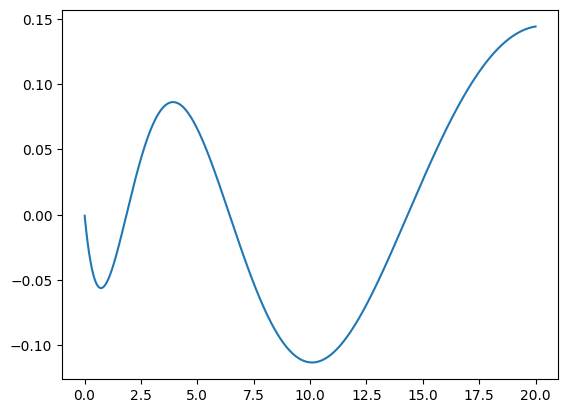

In [91]:
C = msc_basis.constrained_basis('dirichlet', 'dirichlet')
x = np.linspace(-2, 20, 1000)
phi = msc_basis.reconstruct(C @ spec.states[:, 4])

plt.plot(x, phi(x))

In [92]:
print(spec.energies[:10])

[-0.500007   -0.12500088 -0.05555581 -0.03125011 -0.02000006 -0.01388892
 -0.0102041  -0.00781251 -0.00617285 -0.00500001]


I confess the constraining of coefficients is still clumsy, but overall the API is solid and
ridiculously intuitive. Now I'm finally able to compute the beautiful curve I could never approach to:

In [ ]:
np.logspace(-6, 1, 50)

array([1.00000000e-05, 1.32571137e-05, 1.75751062e-05, 2.32995181e-05,
       3.08884360e-05, 4.09491506e-05, 5.42867544e-05, 7.19685673e-05,
       9.54095476e-05, 1.26485522e-04, 1.67683294e-04, 2.22299648e-04,
       2.94705170e-04, 3.90693994e-04, 5.17947468e-04, 6.86648845e-04,
       9.10298178e-04, 1.20679264e-03, 1.59985872e-03, 2.12095089e-03,
       2.81176870e-03, 3.72759372e-03, 4.94171336e-03, 6.55128557e-03,
       8.68511374e-03, 1.15139540e-02, 1.52641797e-02, 2.02358965e-02,
       2.68269580e-02, 3.55648031e-02, 4.71486636e-02, 6.25055193e-02,
       8.28642773e-02, 1.09854114e-01, 1.45634848e-01, 1.93069773e-01,
       2.55954792e-01, 3.39322177e-01, 4.49843267e-01, 5.96362332e-01,
       7.90604321e-01, 1.04811313e+00, 1.38949549e+00, 1.84206997e+00,
       2.44205309e+00, 3.23745754e+00, 4.29193426e+00, 5.68986603e+00,
       7.54312006e+00, 1.00000000e+01])

In [120]:
alpha1 = np.logspace(-1, -6, 30)
alpha2 = np.logspace(-1, 1, 50)
alphas = np.unique(np.concatenate((alpha1[::-1], alpha2)))
alphas

array([1.00000000e-06, 1.48735211e-06, 2.21221629e-06, 3.29034456e-06,
       4.89390092e-06, 7.27895384e-06, 1.08263673e-05, 1.61026203e-05,
       2.39502662e-05, 3.56224789e-05, 5.29831691e-05, 7.88046282e-05,
       1.17210230e-04, 1.74332882e-04, 2.59294380e-04, 3.85662042e-04,
       5.73615251e-04, 8.53167852e-04, 1.26896100e-03, 1.88739182e-03,
       2.80721620e-03, 4.17531894e-03, 6.21016942e-03, 9.23670857e-03,
       1.37382380e-02, 2.04335972e-02, 3.03919538e-02, 4.52035366e-02,
       6.72335754e-02, 1.00000000e-01, 1.09854114e-01, 1.20679264e-01,
       1.32571137e-01, 1.45634848e-01, 1.59985872e-01, 1.75751062e-01,
       1.93069773e-01, 2.12095089e-01, 2.32995181e-01, 2.55954792e-01,
       2.81176870e-01, 3.08884360e-01, 3.39322177e-01, 3.72759372e-01,
       4.09491506e-01, 4.49843267e-01, 4.94171336e-01, 5.42867544e-01,
       5.96362332e-01, 6.55128557e-01, 7.19685673e-01, 7.90604321e-01,
       8.68511374e-01, 9.54095476e-01, 1.04811313e+00, 1.15139540e+00,
      

In [121]:
# alphas = np.logspace(-6, 1, 50)

ground_states = []
first_states  = []
second_states = []

for i, alpha in enumerate(alphas):
    msc = lambda x: MsC_potential_vec(alpha, x) # this is temporary, soon enough Potential will be a callable class

    rm = -3.5*alpha ; rM = 2300 ; N = 500 - 2*i  ; k = 9
    bps = np.logspace( 0, np.log10(rM + 1), N ) - 1 + rm
    # bps = np.logspace( np.log10(rm + 1), np.log10(rM + 1), N ) - 1
    msc_basis = BSplineBasis(bps, k)

    H, S = hamiltonian(representation=msc_basis, potential=msc, 
                       left_bc='dirichlet', right_bc='dirichlet')

    energies, states = solve_eigenproblem(H, S)

    ground_states.append(energies[0])
    first_states.append(energies[1])
    second_states.append(energies[2])

    print(f"Alpha = {alpha} done...")


Alpha = 1e-06 done...
Alpha = 1.487352107293512e-06 done...
Alpha = 2.2122162910704457e-06 done...
Alpha = 3.290344562312664e-06 done...
Alpha = 4.893900918477489e-06 done...
Alpha = 7.2789538439831465e-06 done...
Alpha = 1.082636733874054e-05 done...
Alpha = 1.610262027560939e-05 done...
Alpha = 2.3950266199874812e-05 done...
Alpha = 3.562247890262437e-05 done...
Alpha = 5.298316906283702e-05 done...
Alpha = 7.880462815669905e-05 done...
Alpha = 0.00011721022975334794 done...
Alpha = 0.00017433288221999874 done...
Alpha = 0.0002592943797404667 done...
Alpha = 0.00038566204211634724 done...
Alpha = 0.0005736152510448676 done...
Alpha = 0.0008531678524172806 done...
Alpha = 0.0012689610031679222 done...
Alpha = 0.0018873918221350957 done...
Alpha = 0.0028072162039411755 done...
Alpha = 0.0041753189365604 done...
Alpha = 0.006210169418915616 done...
Alpha = 0.009236708571873866 done...
Alpha = 0.013738237958832623 done...
Alpha = 0.020433597178569417 done...
Alpha = 0.03039195382313198 d

In [122]:
from scipy.interpolate import CubicSpline

Text(0.5, 1.0, 'Energy levels of the MsC potential as a function of alpha')

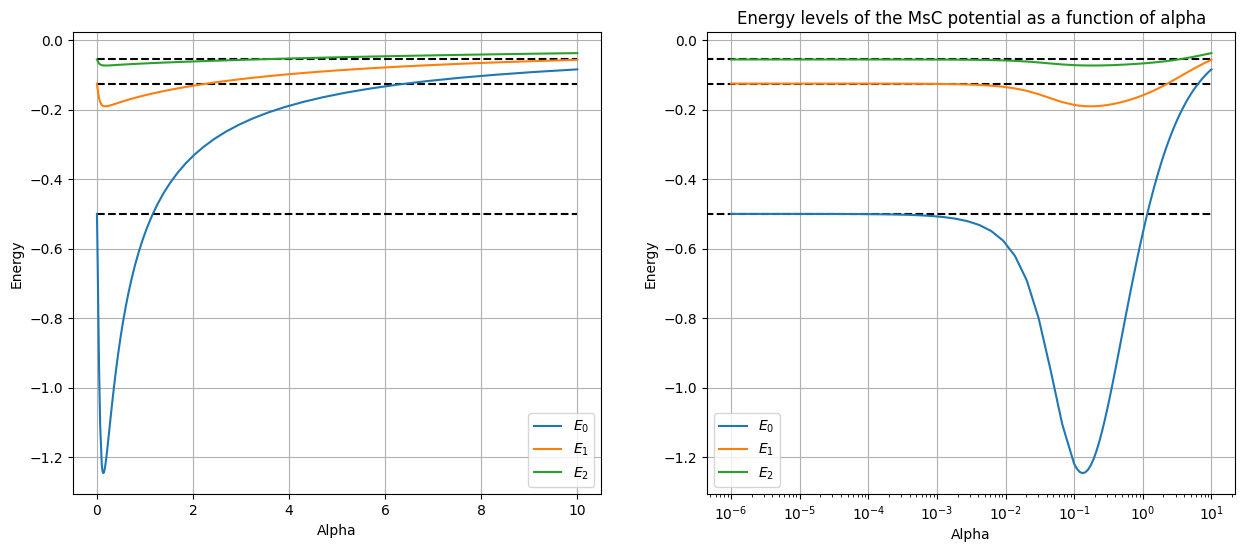

In [123]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
balmer = [-1/(2*n**2) for n in range(1, 4)]

for j in range(2):
    for i in range(3):
        axs[j].hlines(balmer[i], xmin=0, xmax=10, colors='k', linestyles='dashed')


    axs[j].plot(alphas, ground_states, label='$E_0$')
    axs[j].plot(alphas, first_states, label='$E_1$')
    axs[j].plot(alphas, second_states, label='$E_2$')

    axs[j].set_xlabel('Alpha')
    axs[j].set_ylabel('Energy')
    axs[j].legend()
    axs[j].grid()
axs[1].set_xscale('log')
plt.title('Energy levels of the MsC potential as a function of alpha')

In [124]:
alphas[np.argmin(ground_states)]

np.float64(0.13257113655901093)